# 02d — Background Subtraction for All Videos
Takes 4 user-provided background images (one per camera) and produces
background-subtracted versions of every video in a session.
The result is a simplified foreground-only video per file, ideal for
downstream pose estimation.

## How it works
1. You upload one **background image** per camera (photo of the empty pen).
2. The notebook scans all videos in the session folder.
3. For each video, every frame is difference-subtracted against the
   camera’s background, thresholded, and written to a new video file.
4. Output videos are saved to a `background_subtracted/` folder on Drive.

In [11]:
# ===== CONFIGURATION =====

GITHUB_REPO_URL = "https://github.com/kaarthik-balakrishnan/LightningPoseTrack.git"
GIT_BRANCH = "main"

# Google Drive root -- change this to match your Drive structure
DRIVE_ROOT = "/content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior"

OUTPUT_ROOT = "/content/drive/MyDrive/LightningPoseTrack"  # <-- SET THIS

# Paths (change if your folders are at custom locations)
DRIVE_RAW_VIDEOS = f"{DRIVE_ROOT}/260608.00000009"            # Input: session video folders
DRIVE_BACKGROUNDS = f"{OUTPUT_ROOT}/260608.00000009/backgrounds_sub"      # Input: user-provided background images
DRIVE_OUTPUT = f"{OUTPUT_ROOT}/260608.00000009/background_subtracted"     # Output: subtracted videos

# Session to process
SESSION = "260608.00000009"  # <-- SET THIS to your session folder name

# Background subtraction parameters
BG_THRESHOLD = 30       # pixel intensity difference threshold
OUTPUT_FPS = None        # set to a number to force output framerate (None = same as input)

# Background filenames (one per camera, placed in DRIVE_BACKGROUNDS/{SESSION}/)
BG_FILENAME_TEMPLATE = "bg_cam{camera}.jpg"  # e.g. cam1_bg.jpg, cam2_bg.jpg

In [12]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os, sys
REPO_DIR = "/content/LightningPoseTrack"
if not os.path.exists(REPO_DIR):
    !git clone {GITHUB_REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull
%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)

/content/LightningPoseTrack
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 5), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 835.73 KiB | 2.78 MiB/s, done.
From https://github.com/kaarthik-balakrishnan/LightningPoseTrack
   434b38c..2610556  main       -> origin/main
Updating 434b38c..2610556
Fast-forward
 notebooks/02d_Background_Subtraction.ipynb | 748 +++++++++++++++--------------
 1 file changed, 378 insertions(+), 370 deletions(-)
/content/LightningPoseTrack


In [14]:
!apt-get install -y -qq ffmpeg > /dev/null 2>&1
!pip install --quiet opencv-python numpy pandas matplotlib

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

print("Dependencies installed.")

Dependencies installed.


In [15]:
from src.io.video_inventory import scan_videos

df = scan_videos(DRIVE_RAW_VIDEOS)
df = df[df["session"] == SESSION].copy()
print(f"\nFound {len(df)} videos for session {SESSION}")
df[["filename", "camera", "fps", "frame_count", "width", "height"]]

  Root path: /content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior/260608.00000009
  Path exists: True
  First 20 entries: ['004653-4.ASF', '004657-3.ASF', '004659-2.ASF', '004703-1.ASF', '004757-3.ASF', '004756-2.ASF', '004818-4.ASF', '014853-4.ASF', '015213-1.ASF', '015206-2.ASF', '015201-3.ASF', '015156-4.ASF', '015543-4.ASF', '035426-4.ASF', '035429-3.ASF', '035430-2.ASF', '035433-1.ASF', '035603-2.ASF', '035605-3.ASF', '035612-4.ASF']
  004653-4.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004657-3.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004659-2.ASF — OK (h264, 1920x1080, 10.2 fps, 616f)
  004703-1.ASF — OK (h264, 1920x1080, 10.2 fps, 1119f)
  004756-2.ASF — OK (h264, 1920x1080, 10.2 fps, 616f)
  004757-3.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004818-4.ASF — OK (h264, 1920x1080, 10.0 fps, 1861f)
  014853-4.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  015156-4.ASF — OK (h264, 1920x1080, 10.0 fps, 1291f)
  015201-3.ASF — OK (h264, 1920x1080, 10.0 fps, 1021f)
  

,filename,camera,fps,frame_count,width,height
0,004653-4.ASF,4,10.00,601,1920,1080
1,004657-3.ASF,3,10.00,601,1920,1080
2,004659-2.ASF,2,10.25,616,1920,1080
3,004703-1.ASF,1,10.25,1119,1920,1080
4,004756-2.ASF,2,10.25,616,1920,1080
...,...,...,...,...,...,...
122,090307-2.ASF,2,10.25,1129,1920,1080
123,090314-1.ASF,1,10.25,924,1920,1080
124,090409-4.ASF,4,5.00,1396,1920,1080
125,090715-3.ASF,3,10.00,1031,1920,1080


---
## Step 1 — Provide Background Images

**Before running the next cell**, upload one background image per camera to:
```
{DRIVE_ROOT}/backgrounds_sub/{SESSION}/
    cam1_bg.jpg
    cam2_bg.jpg
    cam3_bg.jpg
    cam4_bg.jpg
```
(The filename pattern is set by `BG_FILENAME_TEMPLATE` in the config.)
Each image should be a frame of the **empty pen** (no animal) taken from
the same camera position.

The next cell loads them and shows a preview.

  Loaded camera 1: bg_cam1.jpg (1920x1080)
  Loaded camera 2: bg_cam2.jpg (1920x1080)
  Loaded camera 3: bg_cam3.jpg (1920x1080)
  Loaded camera 4: bg_cam4.jpg (1920x1080)

Loaded 4 / 4 background images


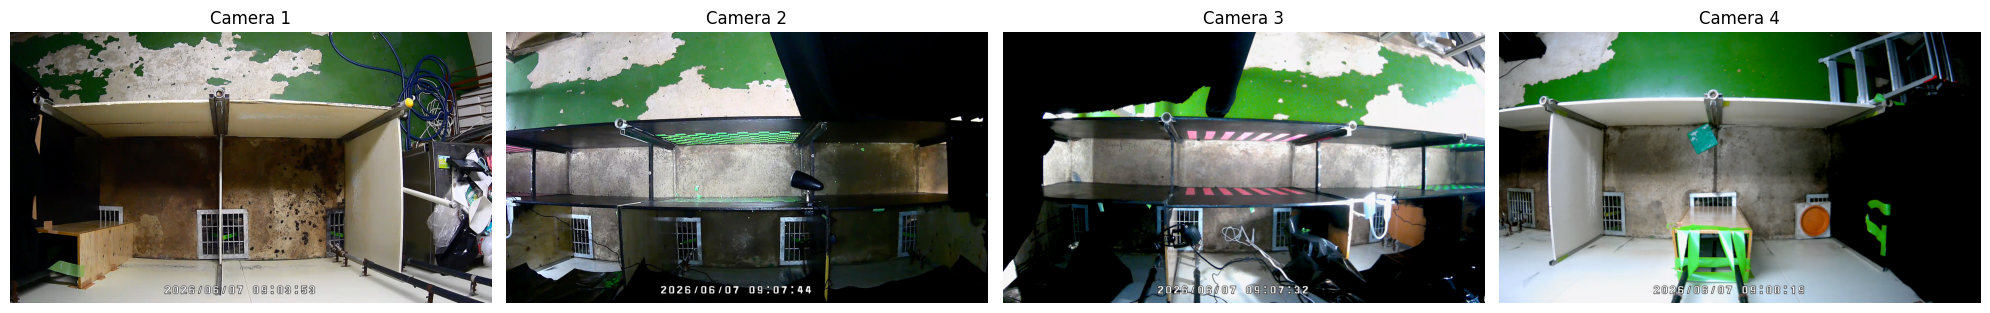

In [16]:
bg_dir = Path(DRIVE_BACKGROUNDS)
bg_dir.mkdir(parents=True, exist_ok=True)

cameras_in_session = sorted(df["camera"].unique())
backgrounds: dict[int, np.ndarray] = {}

for cam in cameras_in_session:
    bg_path = bg_dir / BG_FILENAME_TEMPLATE.format(camera=cam)
    if not bg_path.exists():
        print(f"  MISSING: {bg_path} — upload a background image for camera {cam}")
        continue
    img = cv2.imread(str(bg_path))
    if img is None:
        print(f"  FAILED to load: {bg_path}")
        continue
    backgrounds[cam] = img
    print(f"  Loaded camera {cam}: {bg_path.name} ({img.shape[1]}x{img.shape[0]})")

print(f"\nLoaded {len(backgrounds)} / {len(cameras_in_session)} background images")

# Preview
if backgrounds:
    fig, axes = plt.subplots(1, len(backgrounds), figsize=(5 * len(backgrounds), 4))
    if len(backgrounds) == 1:
        axes = [axes]
    for ax, (cam, bg) in zip(axes, sorted(backgrounds.items())):
        ax.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Camera {cam}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## Step 2 — Background-Subtract All Videos

For each video, every frame is processed:
1. Per-channel RGB absolute difference against the camera’s background
2. Max across channels to get a single difference value per pixel
3. Threshold to keep only pixels that changed significantly
4. Apply the mask to the original frame (keep only foreground in color)
5. Write the color foreground-only frame as the output

Output videos are saved to:
```
{DRIVE_OUTPUT}/{SESSION}/
```

In [ ]:
out_dir = Path(DRIVE_OUTPUT)
out_dir.mkdir(parents=True, exist_ok=True)

FOURCC = cv2.VideoWriter_fourcc(*"mp4v")

results = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing videos"):
    video_path = Path(DRIVE_RAW_VIDEOS) / row["path"]
    cam = row["camera"]
    stem = Path(row["filename"]).stem
    ext = Path(row["filename"]).suffix

    bg = backgrounds.get(cam)
    if bg is None:
        print(f"  Skipping camera {cam} — no background image")
        results.append({"filename": row["filename"], "status": "skipped (no bg)"})
        continue

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  FAILED to open: {row['filename']}")
        results.append({"filename": row["filename"], "status": "failed to open"})
        continue

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_in = cap.get(cv2.CAP_PROP_FPS)
    total_in = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_out = OUTPUT_FPS if OUTPUT_FPS is not None else fps_in

    out_path = out_dir / f"{stem}_bgsub.mp4"
    writer = cv2.VideoWriter(str(out_path), FOURCC, fps_out, (w, h), isColor=True)

    # Resize background to match video dimensions if needed
    bg_resized = cv2.resize(bg, (w, h)) if bg.shape[1] != w or bg.shape[0] != h else bg

    frames_written = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Per-channel absolute difference, then max across channels
        diff = np.max(cv2.absdiff(frame, bg_resized).astype(np.float32), axis=2).astype(np.uint8)
        _, mask = cv2.threshold(diff, BG_THRESHOLD, 255, cv2.THRESH_BINARY)

        # Morphological cleanup: remove small noise, fill gaps
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Apply mask to original frame to keep only foreground in color
        mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        result = cv2.bitwise_and(frame, mask_3ch)
        writer.write(result)
        frames_written += 1

    cap.release()
    writer.release()

    status = f"ok ({frames_written}/{total_in} frames)"
    print(f"  {row['filename']} → {out_path.name}  [{status}]")
    results.append({"filename": row["filename"], "status": status,
                    "output": str(out_path), "frames": frames_written})

summary_df = pd.DataFrame(results)
print(f"\nDone. Processed {len(summary_df)} videos.")
if len(summary_df) > 0:
    print(summary_df[["filename", "status"]].to_string(index=False))

Processing videos:   0%|          | 0/127 [00:00<?, ?it/s]

  004653-4.ASF → 004653-4_bgsub.mp4  [ok (602/602 frames)]
  004657-3.ASF → 004657-3_bgsub.mp4  [ok (576/602 frames)]
  004659-2.ASF → 004659-2_bgsub.mp4  [ok (607/617 frames)]
  004703-1.ASF → 004703-1_bgsub.mp4  [ok (961/1119 frames)]
  004756-2.ASF → 004756-2_bgsub.mp4  [ok (604/617 frames)]


---
## Step 3 — Preview Results

Compare a raw frame with its background-subtracted version.

In [ ]:
# Pick the first successfully-processed video
done = summary_df[summary_df["status"].str.startswith("ok")]
if len(done) == 0:
    print("No processed videos to preview.")
else:
    row = df[df["filename"] == done.iloc[0]["filename"]].iloc[0]
    video_path = Path(DRIVE_RAW_VIDEOS) / row["path"]
    out_path = done.iloc[0]["output"]
    cam = row["camera"]

    cap = cv2.VideoCapture(str(video_path))
    cap_out = cv2.VideoCapture(out_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Show background
    bg_bgr = backgrounds.get(cam)
    if bg_bgr is not None:
        axes[0].imshow(cv2.cvtColor(bg_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Background (Camera {cam})")
    axes[0].axis("off")

    # Pick a middle frame
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    target = total // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, target)

    ret, raw_frame = cap.read()
    ret2, sub_frame = cap_out.read()

    if ret:
        axes[1].imshow(cv2.cvtColor(raw_frame, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Raw frame {target}")
        axes[1].axis("off")

    if ret2:
        axes[2].imshow(cv2.cvtColor(sub_frame, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f"Background-subtracted")
        axes[2].axis("off")

    cap.release()
    cap_out.release()
    plt.tight_layout()
    plt.show()

    print(f"Input:  {row['filename']}")
    print(f"Output: {out_path}")

---
## Next Steps

The background-subtracted videos are ready for pose estimation.
Proceed to **notebook 03** (Pose Training) or **notebook 04** (Pose Inference).

If you need to reprocess with different parameters (e.g.
`BG_THRESHOLD`), just change the settings in the config cell and
re-run **Step 2**.